# AutoValue — Used Car Price Prediction

## 1. Data Loading

In this stage, I load the used-car dataset into a Pandas DataFrame.

The dataset contains vehicle listings collected from Cars.com. My goal is to investigate which vehicle characteristics are useful for predicting a car's price.

Before building a regression model, I first need to understand the structure and quality of the available data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/cars.csv")

## 2. Initial Data Inspection

Before cleaning or transforming the dataset, I inspect its structure.

I want to understand:

- How many observations and features are available?
- What does each column represent?
- Which features are numerical and which are categorical?
- Which feature will be my prediction target?
- Are there missing or unexpected values?

This initial inspection will help me determine how the data should be prepared for regression.

### First Look at the Dataset

After loading the dataset, I displayed the first five rows to understand how the data is structured.

Each row represents a used vehicle listing, while the columns describe different characteristics of the vehicle, seller, and listing.

Some potentially useful features for predicting vehicle price include:

- `manufacturer` — vehicle manufacturer
- `model` — vehicle model
- `year` — model year
- `mileage` — distance the vehicle has been driven
- `engine` — engine description
- `transmission` — transmission type
- `drivetrain` — drivetrain configuration
- `fuel_type` — type of fuel used
- `mpg` — fuel economy
- `accidents_or_damage` — whether accident or damage history is reported
- `one_owner` — whether the vehicle had one owner
- `personal_use_only` — whether the vehicle was used only for personal purposes
- `price` — listed vehicle price and my prediction target

The initial preview also shows that some values are missing, so I will investigate missing data before building the regression model.

In [2]:
df.head()

,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,Parchment,0.0,0.0,0.0,Iconic Coach,NaN,4.4,12.0,300.0,13988.0
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,Kars Today,NaN,4.4,12.0,NaN,17995.0
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0
3,Acura,ILX Hybrid 1.5L,2013,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,Apple Tree Acura,NaN,4.4,12.0,675.0,14958.0
4,Acura,ILX Hybrid 1.5L,2013,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,Herb Connolly Chevrolet,3.7,4.4,12.0,300.0,14498.0


### Dataset Size

The dataset contains **762,091 vehicle listings** and **20 columns**.

Each row represents a used-car listing, while each column represents an attribute related to the vehicle, seller, or listing.

The large number of observations provides enough data to train and evaluate regression models. Before deciding which columns to use as model features, I will inspect their data types and missing values.

In [3]:
df.shape

(762091, 20)

### Dataset Structure

I used `df.info()` to inspect the structure of the dataset, including column data types and the number of non-missing values.

The dataset contains **762,091 observations and 20 columns**. The columns consist of numerical and categorical variables.

Several columns contain missing values. For example, `mileage`, `engine`, `mpg`, `seller_rating`, and `price_drop` have fewer non-null values than the total number of observations.

The target variable, `price`, contains values for all 762,091 observations.

I also observed that some features require further investigation before they can be used for regression. For example, `mpg` is stored as a string rather than a numerical value, while variables such as `accidents_or_damage` and `one_owner` are represented numerically using values such as 0 and 1.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 762091 entries, 0 to 762090
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   manufacturer         762091 non-null  str    
 1   model                762091 non-null  str    
 2   year                 762091 non-null  int64  
 3   mileage              761585 non-null  float64
 4   engine               747041 non-null  str    
 5   transmission         752187 non-null  str    
 6   drivetrain           740529 non-null  str    
 7   fuel_type            739164 non-null  str    
 8   mpg                  620020 non-null  str    
 9   exterior_color       753232 non-null  str    
 10  interior_color       705116 non-null  str    
 11  accidents_or_damage  737879 non-null  float64
 12  one_owner            730608 non-null  float64
 13  personal_use_only    737239 non-null  float64
 14  seller_name          753498 non-null  str    
 15  seller_rating        548118 

## 3. Missing Value Analysis

I inspect the number of missing values in each column before deciding how the data should be cleaned or prepared for regression.

In [5]:
df.isnull().sum()

manufacturer                0
model                       0
year                        0
mileage                   506
engine                  15050
transmission             9904
drivetrain              21562
fuel_type               22927
mpg                    142071
exterior_color           8859
interior_color          56975
accidents_or_damage     24212
one_owner               31483
personal_use_only       24852
seller_name              8593
seller_rating          213973
driver_rating           31632
driver_reviews_num          0
price_drop             351979
price                       0
dtype: int64

## 4. Numerical Summary

I examine descriptive statistics for the numerical features to understand their distributions, ranges, and potential unusual values.

This analysis can help identify issues such as extreme values or unrealistic observations before I use the data to train a regression model.

In [6]:
df.describe()

,year,mileage,accidents_or_damage,one_owner,personal_use_only,seller_rating,driver_rating,driver_reviews_num,price_drop,price
count,762091.000000,7.615850e+05,737879.000000,730608.000000,737239.000000,548118.000000,730459.000000,762091.000000,410112.000000,7.620910e+05
mean,2017.791398,5.578169e+04,0.228616,0.561969,0.657212,4.158568,4.623523,89.550900,1007.467068,3.648898e+04
std,5.110532,4.355788e+04,0.419942,0.496145,0.474642,0.805741,0.276902,115.082266,1375.122208,1.984183e+06
min,1915.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,100.000000,1.000000e+00
25%,2016.000000,2.328700e+04,0.000000,0.000000,0.000000,3.800000,4.500000,14.000000,380.000000,1.958300e+04
50%,2019.000000,4.559600e+04,0.000000,1.000000,1.000000,4.500000,4.700000,51.000000,642.000000,2.798900e+04
75%,2021.000000,7.836500e+04,0.000000,1.000000,1.000000,4.700000,4.800000,119.000000,1007.000000,3.948800e+04
max,2024.000000,1.119067e+06,1.000000,1.000000,1.000000,5.000000,5.000000,1025.000000,170995.000000,1.000000e+09


### Initial Observations from Descriptive Statistics

The numerical summary reveals several characteristics of the dataset that require further investigation before model training.

- Vehicle years range from **1915 to 2024**, although the middle 50% of listings are approximately between **2016 and 2021**.
- The median vehicle mileage is approximately **45,596 miles**, while the maximum exceeds **1.1 million miles**, suggesting possible extreme observations.
- The median listed price is approximately **$27,989**, but prices range from **$1 to $1 billion**. These extreme values may represent unusual listings or data-quality issues and should be investigated before regression.
- `accidents_or_damage`, `one_owner`, and `personal_use_only` are represented numerically as binary 0/1 variables.
- Some numerical features, including `seller_rating` and `price_drop`, contain substantial missing data.
- Several variables show large differences between their typical values and maximum values, indicating that outlier analysis will be important during data preparation.

At this stage, I will not automatically remove unusual observations. I will investigate their distributions and context before deciding how they should be handled.

## 5. Investigating Potential Price Outliers

The descriptive statistics revealed unusually large values in the `price` column, including a maximum listed price of $1 billion.

Rather than automatically removing these observations, I first inspect the most expensive vehicle listings to determine whether they represent legitimate high-value vehicles or potential data-quality issues.

In [7]:
df.nlargest(10, "price")[
    ["manufacturer", "model", "year", "mileage", "price"]
]

,manufacturer,model,year,mileage,price
108142,Chevrolet,Cobalt LT,2009,85185.0,1.000000e+09
188113,Dodge,Durango Citadel,2018,113207.0,1.000000e+09
188260,Dodge,Durango Citadel,2018,113207.0,1.000000e+09
224571,Ford,Utility Police Interceptor Base,2016,NaN,8.888889e+06
84358,Cadillac,DeVille 77 HOURS ON ENGINES,1963,76.0,4.999999e+06
636956,RAM,ProMaster 3500 High Roof,2017,83000.0,3.490000e+06
613085,Porsche,Carrera GT,2005,780.0,2.250000e+06
609009,Porsche,918 Spyder Base (PDK),2015,2622.0,2.099995e+06
613080,Porsche,Carrera GT,2004,2361.0,1.899999e+06
49078,BMW,750 iL,1996,121043.0,1.750000e+06


### Price Outlier Investigation

Inspection of the highest-priced listings shows that the upper end of the target variable contains a mixture of potentially valid high-value vehicles and clearly suspicious observations.

For example, rare vehicles such as the Porsche Carrera GT and Porsche 918 Spyder may legitimately have prices far above those of typical used vehicles. Therefore, a high price alone is not sufficient reason to classify an observation as invalid.

However, the dataset also contains listings such as a 2009 Chevrolet Cobalt and a 2018 Dodge Durango with listed prices of $1 billion. These values are inconsistent with the vehicle characteristics and are likely erroneous or placeholder listing values.

I therefore need to distinguish between legitimate high-value vehicles and likely data-quality errors rather than removing all expensive vehicles using an arbitrary threshold.

## 6. Price Distribution

Since `price` is the target variable for my regression model, I examine its distribution before model training.

The descriptive statistics revealed extremely large price values. I first visualize the complete price distribution to understand how these extreme observations affect the representation of the data.

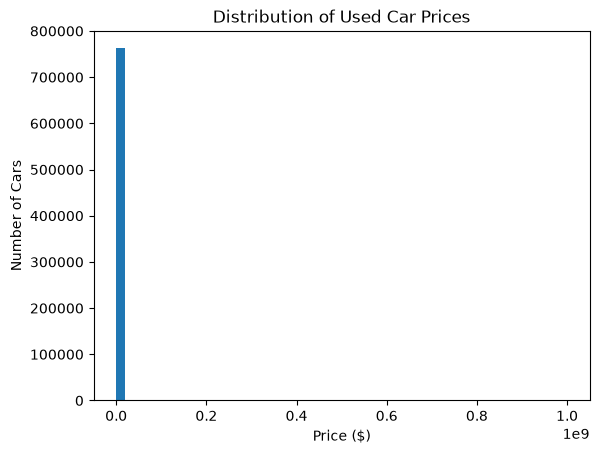

In [8]:
plt.hist(df["price"], bins=50)

plt.xlabel("Price ($)")
plt.ylabel("Number of Cars")
plt.title("Distribution of Used Car Prices")

plt.show()

In [9]:
df["price"].quantile(0.99)

np.float64(109995.0)

### Examining the Typical Price Range

The full histogram is heavily compressed because a small number of extremely large price values extend the x-axis far beyond the range containing most vehicle listings.

To obtain a more informative visualization without deleting observations from the dataset, I examine the 99th percentile of `price`. This identifies the price below which approximately 99% of the observations fall.

### Price Distribution Below the 99th Percentile

The 99th percentile of vehicle price is **$109,995**, meaning approximately 99% of the listings have prices at or below this value.

I use this percentile only to create a more informative visualization of the main price distribution. At this stage, observations above this threshold are not permanently removed from the dataset.

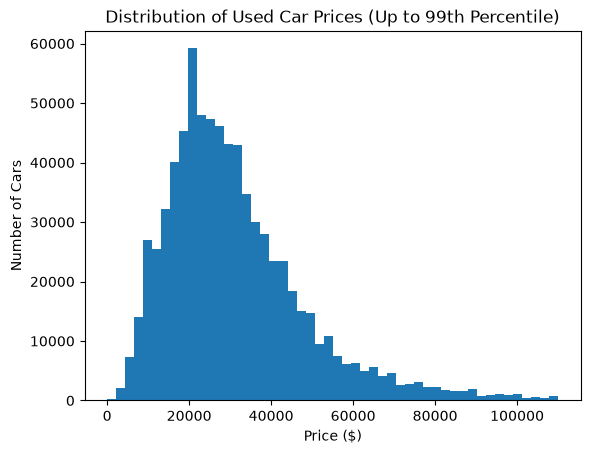

In [10]:
price_99 = df["price"].quantile(0.99)

price_filtered = df[df["price"] <= price_99]

plt.hist(price_filtered["price"], bins=50)

plt.xlabel("Price ($)")
plt.ylabel("Number of Cars")
plt.title("Distribution of Used Car Prices (Up to 99th Percentile)")

plt.show()

### Interpretation

After restricting the visualization to the 99th percentile, the main price distribution becomes much clearer.

The distribution is **right-skewed**. Most used vehicles are concentrated in the lower and middle price ranges, while progressively fewer vehicles appear at higher prices, producing a long right tail.

This also helps explain why the mean price is higher than the median price: relatively expensive vehicles pull the mean upward.

The visualization confirms that extreme price observations can significantly distort the full distribution. However, the 99th-percentile threshold is currently used only for visualization and is not yet a rule for removing training observations.

## 7. Relationship Between Mileage and Price

Mileage is one of the numerical features that I expect to influence used-car prices.

My initial hypothesis is that vehicles with higher mileage will generally have lower prices because they have experienced greater usage and wear.

I visualize the relationship between `mileage` and `price` to determine whether the dataset supports this hypothesis.

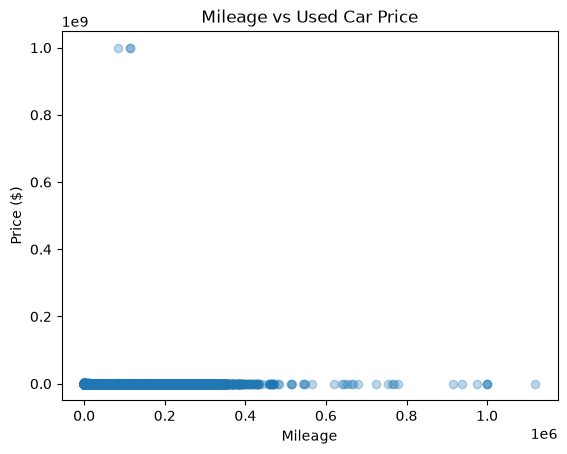

In [11]:
plt.scatter(df["mileage"], df["price"], alpha=0.3)

plt.xlabel("Mileage")
plt.ylabel("Price ($)")
plt.title("Mileage vs Used Car Price")

plt.show()

### Adjusting the Visualization for Extreme Values

The initial scatter plot was difficult to interpret because extreme values in both `price` and `mileage` stretched the plot axes and compressed the majority of observations.

To better visualize the relationship between mileage and price, I restrict the visualization to observations within the 99th percentile of both variables.

This filtering is performed only for visualization and does not permanently remove observations from the original dataset.

In [12]:
mileage_99 = df["mileage"].quantile(0.99)
mileage_99

np.float64(193606.4800000001)

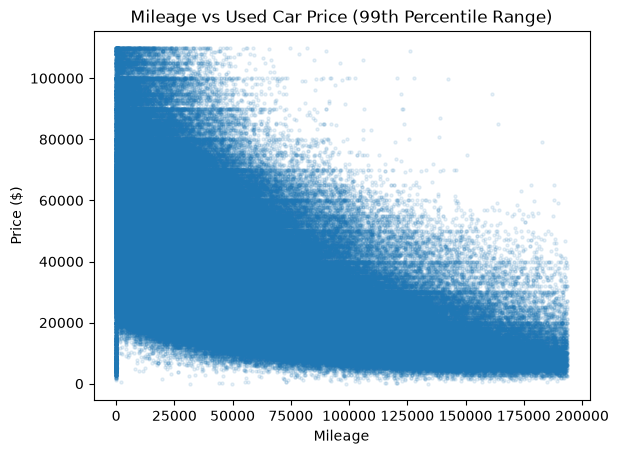

In [13]:
plot_data = df[
    (df["price"] <= price_99) &
    (df["mileage"] <= mileage_99)
]

plt.scatter(
    plot_data["mileage"],
    plot_data["price"],
    alpha=0.1,
    s=5
)

plt.xlabel("Mileage")
plt.ylabel("Price ($)")
plt.title("Mileage vs Used Car Price (99th Percentile Range)")

plt.show()

### Interpretation

The scatter plot shows a general negative relationship between mileage and vehicle price. As mileage increases, vehicle prices tend to decrease.

This supports my initial hypothesis that higher-mileage vehicles generally have lower market values.

However, the substantial vertical spread in prices at similar mileage levels shows that mileage alone cannot explain vehicle price. Cars with similar mileage can have very different prices, indicating that other characteristics such as model year, manufacturer, model, engine, and drivetrain may also influence price.

This suggests that a multiple-feature regression model may provide better predictions than a model based only on mileage.

## 8. Relationship Between Model Year and Price

Model year is another numerical feature that I expect to influence used-car prices.

My hypothesis is that newer vehicles will generally have higher prices than older vehicles. Since a larger `year` value represents a newer vehicle, I expect a positive relationship between `year` and `price`.

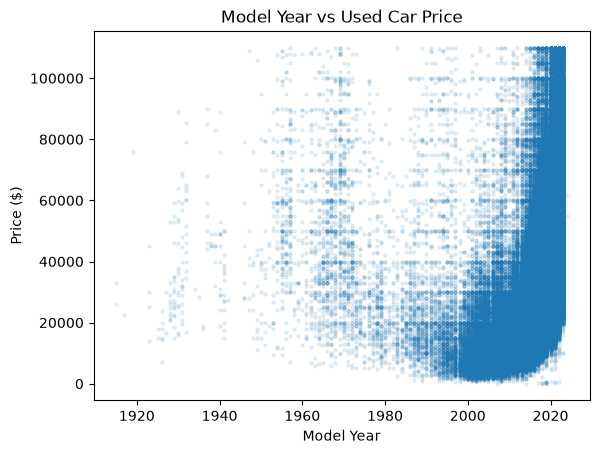

In [14]:
year_plot_data = df[df["price"] <= price_99]

plt.scatter(
    year_plot_data["year"],
    year_plot_data["price"],
    alpha=0.1,
    s=5
)

plt.xlabel("Model Year")
plt.ylabel("Price ($)")
plt.title("Model Year vs Used Car Price")

plt.show()

### Interpretation

The scatter plot suggests a generally positive relationship between model year and vehicle price, particularly among more recent vehicles. Newer vehicles tend to have higher prices than older vehicles.

However, the relationship is not perfectly linear. Some older vehicles also have relatively high prices, which may represent classic, collectible, or otherwise unusual vehicles.

The large variation in price among vehicles from the same model year also indicates that model year alone cannot explain vehicle price.

The apparent non-linearity provides a reason to later compare a linear regression model with a polynomial regression model rather than assuming that a straight-line relationship is sufficient.

## 9. Correlation Analysis

After visually examining the relationships between individual numerical features and vehicle price, I use correlation analysis to quantify the strength and direction of their linear relationships.

The correlation coefficient ranges from -1 to +1:

- Values closer to **+1** indicate a stronger positive linear relationship.
- Values closer to **-1** indicate a stronger negative linear relationship.
- Values closer to **0** indicate a weak linear relationship.

Correlation measures association rather than causation, and a low correlation does not necessarily mean that a feature has no predictive value.

In [15]:
correlation_features = df[
    ["year", "mileage", "price"]
]

correlation_features.corr()

,year,mileage,price
year,1.000000,-0.527940,0.002154
mileage,-0.527940,1.000000,-0.003171
price,0.002154,-0.003171,1.000000


### Effect of Extreme Values on Correlation

The initial correlation matrix shows almost no linear correlation between `price` and either `year` or `mileage`, despite patterns visible in the scatter plots.

One possible explanation is that the correlation calculation uses the full dataset, including extreme price and mileage observations identified earlier.

To investigate this, I recalculate the correlations using the same 99th-percentile range used for visualization. This comparison helps determine whether extreme observations are masking relationships within the majority of the dataset.

In [16]:
plot_data[
    ["year", "mileage", "price"]
].corr()

,year,mileage,price
year,1.000000,-0.522488,0.382812
mileage,-0.522488,1.000000,-0.556534
price,0.382812,-0.556534,1.000000


### Interpretation

The correlations change substantially when the analysis is restricted to the main 99% range of `price` and `mileage`.

For the full dataset, the correlations between `price` and both `year` and `mileage` were close to zero. After limiting the analysis to the 99th-percentile range:

- `year` and `price` have a correlation of approximately **+0.38**, indicating a moderate positive linear relationship.
- `mileage` and `price` have a correlation of approximately **-0.56**, indicating a moderate negative linear relationship.
- `year` and `mileage` have a correlation of approximately **-0.52**, showing that newer vehicles generally have lower mileage.

This comparison demonstrates that extreme observations can substantially distort correlation statistics and mask relationships present in the majority of the data.

However, the 99th-percentile thresholds were introduced for exploratory analysis and have not yet been adopted as permanent rules for removing training observations.

# Phase 2 — Data Cleaning and Feature Preparation

Before training a regression model, I need to convert the raw dataset into data that represents the prediction problem appropriately.

During this stage, I will:

- investigate and handle invalid or extreme observations
- decide how to handle missing values
- select useful predictor features
- identify features that could introduce leakage
- prepare numerical and categorical variables for regression
- separate the predictor variables (`X`) from the target variable (`y`)

I will make these decisions based on the meaning and quality of the data rather than automatically removing every unusual or missing observation.

### Prediction Objective and Feature Availability

The objective of my model is to estimate the expected listing price of a used vehicle from information that would reasonably be available before the vehicle is priced.

For this reason, I distinguish between vehicle characteristics and information generated during the listing process.

For example, `price_drop` describes a change in an existing listing price. Since this information would not necessarily exist when estimating the initial value of a vehicle, I will not use it as a predictor in the initial model.

This helps ensure that the features used during model training are also available when the model is used to make new predictions.

In [17]:
target = "price"

vehicle_features = [
    "manufacturer",
    "model",
    "year",
    "mileage",
    "engine",
    "transmission",
    "drivetrain",
    "fuel_type",
    "mpg",
    "accidents_or_damage",
    "one_owner",
    "personal_use_only"
]

listing_features = [
    "seller_name",
    "seller_rating",
    "driver_rating",
    "driver_reviews_num",
    "price_drop"
]

In [ ]:
## 11. Handling Extreme Target Values

The exploratory analysis identified several extremely large values in the target variable `price`.

However, an expensive vehicle is not necessarily an invalid observation. Rare, luxury, and collectible vehicles can legitimately have prices far above those of typical used cars.

Therefore, I do not remove observations solely because they exceed the 99th percentile. Instead, I first examine how many listings occur at increasingly high price thresholds and use this information together with vehicle context to distinguish plausible high-value listings from likely data-quality errors.

In [18]:
print("Above $100K:", (df["price"] > 100_000).sum())
print("Above $250K:", (df["price"] > 250_000).sum())
print("Above $500K:", (df["price"] > 500_000).sum())
print("Above $1M:", (df["price"] > 1_000_000).sum())
print("Above $5M:", (df["price"] > 5_000_000).sum())

Above $100K: 9898
Above $250K: 617
Above $500K: 57
Above $1M: 28
Above $5M: 4


In [19]:
print("Below $100:", (df["price"] < 100).sum())
print("Below $500:", (df["price"] < 500).sum())
print("Below $1K:", (df["price"] < 1_000).sum())
print("Below $2K:", (df["price"] < 2_000).sum())
print("Below $5K:", (df["price"] < 5_000).sum())

Below $100: 4
Below $500: 16
Below $1K: 39
Below $2K: 209
Below $5K: 4420


### Investigating the Target Range

The threshold analysis shows that high-priced vehicles are relatively uncommon but not necessarily invalid. For example, the dataset contains thousands of vehicles priced above $100,000, while only a small number exceed $1 million.

Because legitimate luxury and collectible vehicles exist in these ranges, I avoid treating a high price alone as evidence of erroneous data.

The descriptive statistics also revealed a minimum price of only $1. I therefore investigate the lower end of the target distribution before defining the modelling population.

Rather than automatically excluding high-priced vehicles, I retain legitimate luxury and high-value vehicles for later modelling and evaluation. This allows me to investigate whether the same regression model can generalize across different segments of the used-car market.

My initial cleaning therefore focuses on clearly implausible target values rather than removing observations simply because they are expensive.

In [21]:
df.nsmallest(15, "price")[
    ["manufacturer", "model", "year", "mileage", "price"]
]

,manufacturer,model,year,mileage,price
5658,Acura,TLX V6 A-Spec,2018,49603.0,1.0
13850,Audi,A4 2.0T Premium,2014,98881.0,1.0
660696,Subaru,Legacy 2.5i Limited,2019,31570.0,1.0
735177,Volkswagen,Jetta,2007,133964.0,1.0
584638,Nissan,Versa SV,2021,45288.0,259.0
195371,Ford,EcoSport Titanium,2019,44077.0,289.0
66049,Buick,Enclave Premium,2017,115869.0,299.0
73551,Buick,Encore Essence,2019,115608.0,299.0
599832,Nissan,Murano SV,2018,120524.0,299.0
600748,Nissan,Murano SV,2018,120524.0,299.0


## 12. Cleaning Implausible Target Values

Inspection of the lowest-priced observations revealed values such as $1, $259, and $399 for relatively recent vehicles. These values are unlikely to represent realistic vehicle listing prices and may result from placeholder values, scraping errors, or other data-quality issues.

I therefore remove observations with prices below $1,000.

I do not apply an upper price threshold at this stage because high prices can represent legitimate luxury or collectible vehicles. Retaining these observations will also allow me to later evaluate whether the regression model performs differently across market segments.

In [22]:
clean_df = df[df["price"] >= 1_000].copy()

print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))

Original rows: 762091
Cleaned rows: 762052
Rows removed: 39


## 13. Missing Value Analysis

The dataset contains missing values across several features. Before deciding how to handle them, I calculate the percentage of missing observations for each column.

Different features may require different strategies depending on how much data is missing, the meaning of the feature, and whether the feature will be used by the prediction model.

In [23]:
missing_values = clean_df.isnull().sum()

missing_percentage = (
    clean_df.isnull().mean() * 100
)

missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percentage": missing_percentage
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    "missing_percentage",
    ascending=False
)

missing_summary

,missing_count,missing_percentage
price_drop,351947,46.184119
seller_rating,213956,28.076299
mpg,142066,18.642560
interior_color,56968,7.475605
driver_rating,31632,4.150898
one_owner,31479,4.130820
personal_use_only,24848,3.260670
accidents_or_damage,24208,3.176686
fuel_type,22926,3.008456
drivetrain,21561,2.829334


In [ ]:
### Handling Missing Mileage

`mileage` is an important predictor for vehicle price, but only approximately 0.07% of observations are missing this value.

Because the dataset contains more than 760,000 observations, removing these few records results in negligible data loss. I therefore remove observations with missing mileage rather than introducing estimated mileage values through imputation.

In [24]:
clean_df = clean_df.dropna(subset=["mileage"]).copy()

print("Rows remaining:", len(clean_df))

Rows remaining: 761547


## 14. Feature Engineering — Vehicle Age

Model year is useful for predicting vehicle price, but vehicle age provides a more intuitive representation of depreciation.

I create a `vehicle_age` feature by subtracting the model year from the reference year associated with the dataset.

Using vehicle age also makes the model easier to interpret: a positive coefficient would mean price increases with age, while a negative coefficient would indicate depreciation as vehicles become older.

In [25]:
REFERENCE_YEAR = 2024

clean_df["vehicle_age"] = REFERENCE_YEAR - clean_df["year"]

In [26]:
clean_df[
    ["year", "vehicle_age", "mileage", "price"]
].head()

,year,vehicle_age,mileage,price
0,2013,11,92945.0,13988.0
1,2013,11,47645.0,17995.0
2,2013,11,53422.0,17000.0
3,2013,11,117598.0,14958.0
4,2013,11,114865.0,14498.0


In [27]:
clean_df["vehicle_age"].describe()

count    761547.000000
mean          6.206587
std           5.100222
min           0.000000
25%           3.000000
50%           5.000000
75%           8.000000
max         109.000000
Name: vehicle_age, dtype: float64

### Vehicle Age Interpretation

The engineered `vehicle_age` feature ranges from 0 to 109 years, which is consistent with the model-year range observed in the dataset.

I expect vehicle age to have a negative relationship with price because vehicles generally depreciate as they become older.

Since `vehicle_age` is directly derived from `year`, I will not include both features simultaneously in the same regression model. I will use `vehicle_age` because it provides a more intuitive representation of vehicle depreciation.

## 15. Feature Engineering — Mileage Per Year

Total mileage does not capture how intensively a vehicle has been driven relative to its age.

For example, a two-year-old vehicle with 80,000 miles has experienced substantially heavier annual usage than a ten-year-old vehicle with the same mileage.

I therefore explore a `mileage_per_year` feature that combines vehicle age and total mileage to represent average annual usage.

In [31]:
clean_df["mileage_per_year"] = (
    clean_df["mileage"] /
    clean_df["vehicle_age"].clip(lower=1)
)

In [32]:
clean_df[
    ["vehicle_age", "mileage", "mileage_per_year", "price"]
].head()

,vehicle_age,mileage,mileage_per_year,price
0,11,92945.0,8449.545455,13988.0
1,11,47645.0,4331.363636,17995.0
2,11,53422.0,4856.545455,17000.0
3,11,117598.0,10690.727273,14958.0
4,11,114865.0,10442.272727,14498.0


In [33]:
clean_df["mileage_per_year"].describe()

count    761547.000000
mean       9227.610405
std        5243.185382
min           0.000000
25%        5611.600000
50%        8602.523810
75%       12141.600000
max      305127.666667
Name: mileage_per_year, dtype: float64

## 16. Baseline Model Preparation

I begin modelling with a simple linear regression baseline using `mileage` as the only predictor of vehicle price.

Starting with a simple model provides a reference point against which I can measure whether additional features and more flexible regression models actually improve predictive performance.

The initial relationship is:

\[
\text{price} = w(\text{mileage}) + b
\]

I will later extend this baseline by incorporating vehicle age, engineered features, and nonlinear relationships.

In [35]:
X = clean_df[["mileage"]]
y = clean_df["price"]

In [36]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (761547, 1)
y shape: (761547,)


In [ ]:
## 17. Train-Test Split

To evaluate how well the model generalizes to unseen vehicle listings, I divide the dataset into separate training and test sets.

I use 80% of the observations for training and reserve 20% for testing. The model learns its parameters from the training data only, while the test set is kept unseen during training and is later used to evaluate predictive performance.